The goal of this notebook is to illustrate how to download Google Street View (GSV) images for a specific area. The workflow will follow the process below:

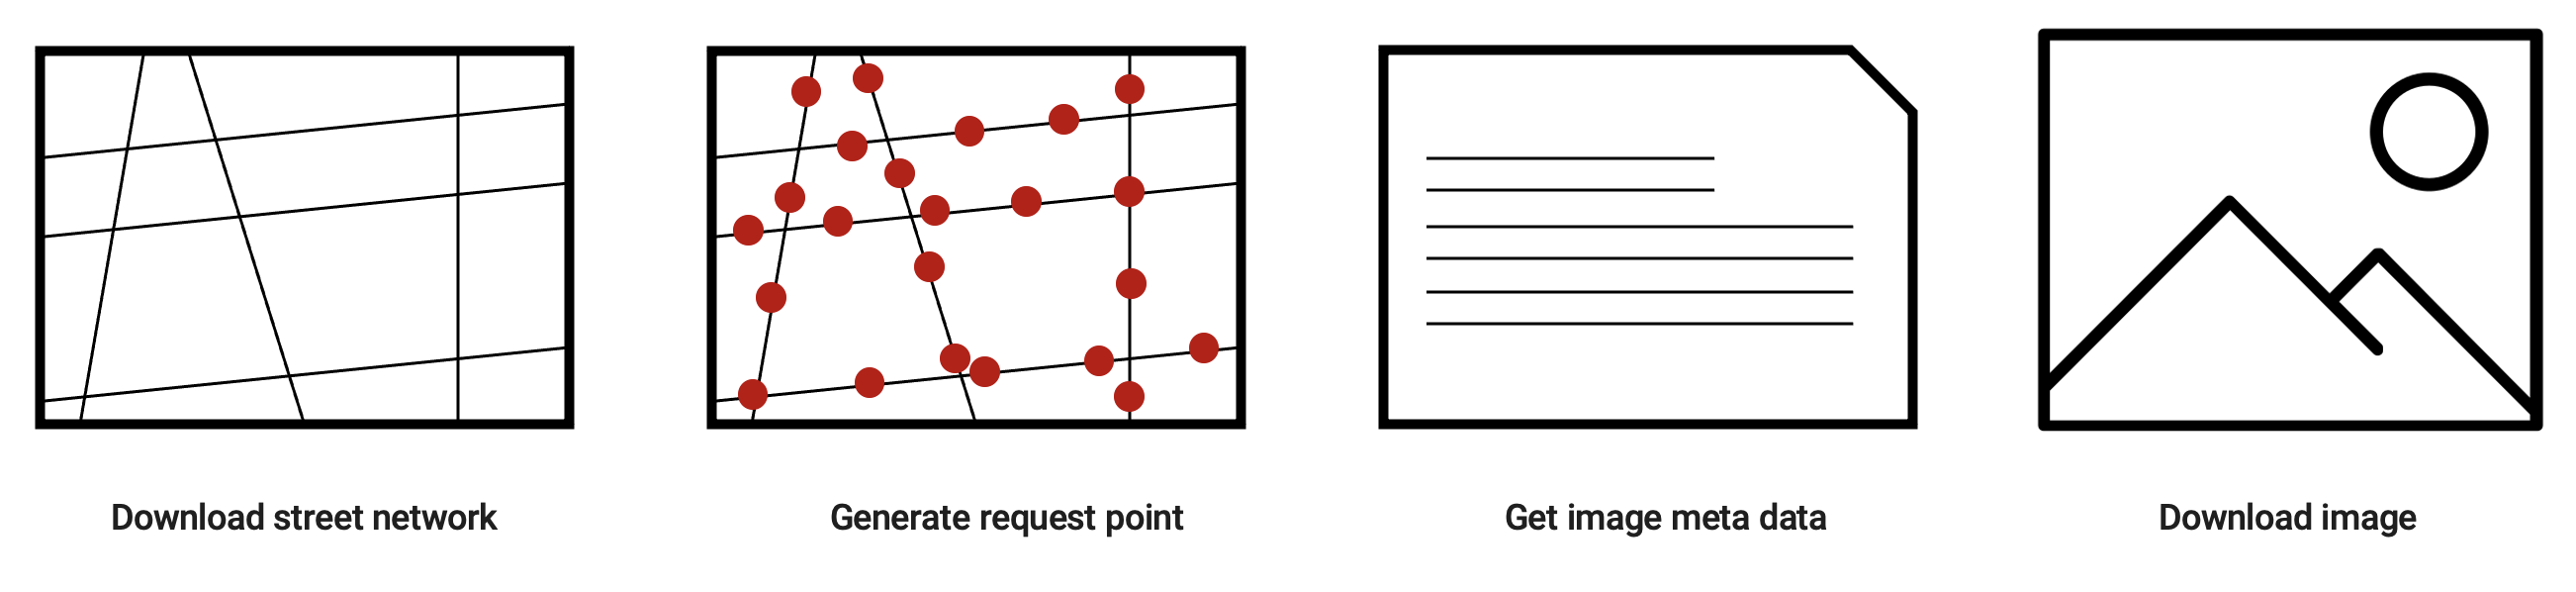

**1. Download street network of the area**

**2. Generate random points from street network we downloaded from Step 1**

**3. Request GSV image metadata**

Metadata contains the panoID(this id is unique among all the GSV), actual location, time (year and month) where the GSV was taken

**4. Download GSV image**

Download the actual image to drive




## 0 Setup
First, run the next code block to setup.

Google CoLab environment does not have some libraries ready, run the code block below to install the required library

After installing, restart the runtime by *Runtime -> Restart Runtime*

In [ ]:
!pip install osmnx &> /dev/null
!pip install matplotlib==3.1.3 &> /dev/null

The goal of this notebook is to download actual image from GSV server, we need store the images somewhere. In this notebook, we show how to connect to google drive and store the results to Google Drive folder.

If you follow the tutorial, you can find all the images in **/Colab Notebooks/result/img** folder under your google drive root folder.

In [ ]:
import os, sys
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
workshop_folder = "..."
save_path = f"{workshop_folder}..."

In [ ]:
if not os.path.exists(save_path):
    os.makedirs(save_path, exist_ok=True)

Run the next code block to import libraries for this lab.

In [ ]:
import osmnx as ox
import numpy as np
import pandas as pd
import geopandas as gpd

from PIL import Image
from io import BytesIO

import requests
from tqdm import tqdm
import time
import matplotlib.pyplot as plt


## 1 Generate street network

Code below downloads street network from openstreetmap

In [ ]:
def obtain_street_network_grid(north, south, east, west):
  """
  This function downloads street network within a rectangular area
  input: north, south, east, west coordinates of the area
  output: GeoDataFrame, each row represents one street segment
  """
  # obtain street network from OpenStreetMap
  # network_type will simplify the network, here we only download drive way
  bbox = (west, south, east, north)
  G = ox.graph_from_bbox(bbox=bbox, truncate_by_edge=True, network_type='drive')
  # convert downloaded street network to GeoDataFrame
  _, edge = ox.graph_to_gdfs(G)
  # plot downloaded street network
  ox.plot_graph(G)

  return edge


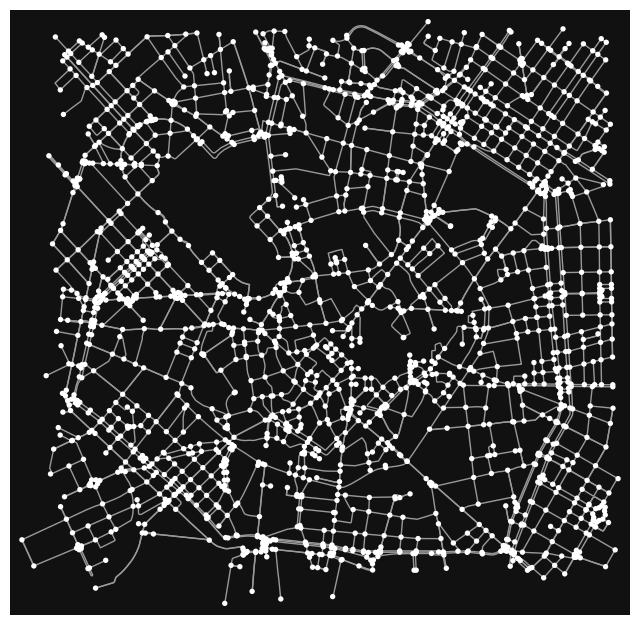

In [ ]:
# north, south, east, west
street = obtain_street_network_grid(45.00, 45.00, 45.00, 45.00)

## 2 Generate points on street to request GSV

In [ ]:
def street2Point(roadDF, interval_meters=50.0, out_crs="EPSG:4326"):
    if roadDF.crs is None:
        raise ValueError("roadDF.crs is None. Set a CRS first (e.g., roadDF = roadDF.set_crs('EPSG:4326')).")
    roadDF = roadDF.copy()
    roadDF["ref"] = 1
    dissolved = roadDF.dissolve(by="ref")  # GeoDataFrame with single row
    dissolved_m = dissolved.to_crs(dissolved.estimate_utm_crs())
    geom = dissolved_m.geometry.iloc[0]
    total_len_m = geom.length  # meters
    dists = np.arange(0.0, total_len_m + 1e-9, float(interval_meters))
    points_m = [geom.interpolate(d) for d in dists]
    pts_gdf_m = gpd.GeoDataFrame(geometry=points_m, crs=dissolved_m.crs)
    pts_gdf_m = pts_gdf_m.loc[~pts_gdf_m.geometry.to_wkt().duplicated()].reset_index(drop=True)
    pts_ll = pts_gdf_m.to_crs(out_crs)
    out = pd.DataFrame({
        "id": np.arange(len(pts_ll), dtype=int),
        "lon": pts_ll.geometry.x.round(5),
        "lat": pts_ll.geometry.y.round(5),
    })
    return out

In [ ]:
requestPoint = street2Point(street, interval_meters=50)
display(requestPoint.head(10))

,id,lon,lat
0,0,9.19096,45.46066
1,1,9.19100,45.46062
2,2,9.20482,45.45805
3,3,9.20598,45.46019
4,4,9.20045,45.46191
5,5,9.20036,45.46147
6,6,9.20027,45.46102
7,7,9.20096,45.46225
8,8,9.21074,45.46231
9,9,9.16432,45.46135


In [ ]:
requestPoint.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      2392 non-null   int64  
 1   lon     2392 non-null   float64
 2   lat     2392 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 56.2 KB


## 3 Request Google Street View image metadata

Starting from this step, you will need to feed your GSV API key in order to make requests to GSV server. In next

In [ ]:
# Starting from this step, you will need to feed your GSV API key in order to make requests to GSV server. In the line below, please replace 'xxx' with your own key
apiKey = '...'

In [ ]:
def GSV_meta_single(lat, lon, apiKey):
  """
  This function obtains GSV metadata at one single request point
  input: latitude and longitude of the request point, api key of your Google Cloud account
  output: dictionary with time, latitude, longitude and panoID of the GSV at the request point
  """
  # original request url for API call
  meta_url = "https://maps.googleapis.com/maps/api/streetview/metadata?size=600x400&location={},{}&key={}"
  # format the request url with feeded parameters
  request_url = meta_url.format(lat, lon, apiKey)
  try:
      # request and format the metadata
      response = requests.get(request_url).json()
      # return metadata if GSV exists
      return {'date':response['date'], 'lat':response['location']['lat'], 'lon':response['location']['lng'], 'panoID':response['pano_id']}
  except Exception as e:
    print(f"An error occurred: {e}")
    return None

In [ ]:
# construct a list to store all information
metas = []
# iterate over requestPoint DataFrame and request GSV metadata
for i, row in tqdm(requestPoint.iterrows()):
    # obtain metadata for each point
    meta = GSV_meta_single(row['lat'], row['lon'], apiKey)
    # if GSV meta data is successfully downloaded and formatted, save the information
    if meta != None:
        metas.append(meta)
    # time.sleep(0.1)

# convert stored information to DataFrame
panoidDF = pd.DataFrame(metas, columns=['date', 'lat', 'lon', 'panoID'])

2392it [04:02,  9.86it/s]


Quantity of Images

In [ ]:
print("Valid GSV panoIDs:", len(panoidDF))
print("Expected total images to download:", len(panoidDF) * 4)

Valid GSV panoIDs: 2392
Expected total images to download: 9568


In [ ]:
# inspect downloaded GSV meta data
panoidDF.head(5)

,date,lat,lon,panoID
0,2025-08,45.460672,9.190985,0irF1iZJhatmLJYNsE8Gkw
1,2022-05,45.460591,9.191054,ln1FE-r2l4ZXoju1Dji9yg
2,2024-09,45.458043,9.204846,UwgdgrWgwsTHnP9aWVb4IA
3,2025-08,45.460188,9.205980,T1i3eSAiHsCbR0CWyYl9Zw
4,2025-08,45.461871,9.200438,zaMKmNUlQVoLcaVt8uP2OA


In [ ]:
panoidDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    2392 non-null   object 
 1   lat     2392 non-null   float64
 2   lon     2392 non-null   float64
 3   panoID  2392 non-null   object 
dtypes: float64(2), object(2)
memory usage: 74.9+ KB


In [ ]:
panoidDF.to_csv(f"{workshop_folder}...", index=False)

## 4 Request Google Street View images

In [ ]:
#If downloading later
#panoidDF = pd.read_csv(f"{workshop_folder}...")

In [ ]:
def GSV_single(panoID, heading, apiKey, pitch=0, fov=90, width=640, height=640):
  """
  This function downloads GSV image with panoID and other customized parameters
  input:
    panoID: unique ID obtained from GSV meta data
    heading: horizontal angle the camera is pointing at
    pitch: vertical angle the camera is pointing at
    fov: zoom level of the image
  output:
    PIL Image object
  """
  # format the request url for downloading image
  request_url = "https://maps.googleapis.com/maps/api/streetview?size={}x{}&pano={}&heading={}&fov={}&pitch={}&key={}".format(width, height, panoID, heading, fov, pitch, apiKey)
  # request image and return
  try:
      response = requests.get(request_url)
      return Image.open(BytesIO(response.content))
  except Exception as e:
    print(f"An error occurred: {e}")
    return None

In [ ]:
for idx, row in tqdm(panoidDF.iterrows()):
    for heading in [0,90,180,270]:
      img = GSV_single(panoID=row['panoID'], apiKey=apiKey, heading=heading)
      img.save(os.path.join(save_path, '{}_{}.jpg'.format(row['panoID'], heading)), 'jpeg')

2392it [24:49,  1.61it/s]


Check downloaded images

In [ ]:
def check_all_images(row, path):
    # Returns True only if all 4 files exist
    return all(os.path.isfile(f"{path}/{row['panoID']}_{h}.jpg") for h in [0, 90, 180, 270])

# Use a list comprehension to create a boolean mask
mask = [check_all_images(row, save_path) for _, row in tqdm(panoidDF.iterrows(), total=len(panoidDF))]

# Filter the original dataframe
good_df = panoidDF[mask].copy()
print("Downloaded PanoIDs:",len(good_df))

100%|██████████| 10/10 [00:00<00:00, 549.40it/s]

Downloaded PanoIDs: 10


In [ ]:
# good_df.to_csv(f"{workshop_folder}/GSV_Download/panoid_MIT_good.csv")

Now go to the folder *VisualAI_tutorials/demo0_GSV_download/img*, you should find the downloaded images!

VISUALIZE DOWNLOAD LOCATIONS

In [ ]:
import folium
import io

In [ ]:
zoom_level = 15

In [ ]:
center = [panoidDF['lat'].mean(), panoidDF['lon'].mean()]

In [ ]:
# include visualisation
theme = 'CartoDB dark_matter'
#theme  = 'openstreetmap'
#theme = 'cartodbpositron'
map0 = folium.Map(location=center,tiles=theme,zoom_start=zoom_level)
# Display the map0

# 2.5 Paint the dataframe data with dots on the map

# Read the Lat and Lng and paint with color

for index, row in panoidDF.iterrows():
  folium.CircleMarker([row['lat'], row['lon']],radius=.01,fill=True, color='green',opacity=1, fill_color='green',fill_opacity=1).add_to(map0)

map0